# When does model complexity actually pay off?
### Predicting US flight-departure disruption two hours before departure

**Sabarish G** · MSc Business Analytics · Portfolio project 1 of 3 · public data only (US DOT / BTS on-time performance)

*A flight is **disrupted** if it departs 15+ minutes late or is cancelled. We predict that probability for every
scheduled US domestic flight at **t\* = 2 hours before scheduled departure**, using only what an observer could know at
that instant, and climb a ladder of increasingly complex models to see where the extra complexity stops earning its keep.*

> **How to read this notebook.** Recruiters: read the 30-second version and look at the first chart. Data scientists:
> every section states the decision taken, why, and the check that proves it. Every number is computed from
> `results/metrics/*.json`, which the pipeline writes; nothing is typed by hand.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from flightrisk import pipeline
from flightrisk.reporting import story as st
from flightrisk.reporting.metrics_io import read_metric
from flightrisk.viz import figures as F
from flightrisk.viz import style as S

pd.set_option("display.max_colwidth", 140)
# Rebuild anything that is missing, in order (a fresh clone with the raw zip runs every stage).
status = pipeline.ensure_all(log=lambda *a: None)

def show(name):
    fig = F.ALL[name]()
    S.save(fig, name)
    plt.show()

def table(df):
    display(df.style.hide(axis="index").set_properties(**{"text-align": "left"}))

def md(s):
    display(Markdown(s))

missing = [k for k, v in status.items() if not v]
md(f"*Pipeline: {sum(status.values())} of {len(status)} stages present"
   + (f"; missing: {', '.join(missing)}*" if missing else " (every artefact below was produced by code in `src/` and `scripts/`).*"))

*Pipeline: 13 of 13 stages present (every artefact below was produced by code in `src/` and `scripts/`).*

## The 30-second version

In [2]:
md(st.headline_md())

**Question.** Two hours before departure, how well can we predict whether a US flight will be disrupted (15+ min late or cancelled), and when does a more complex model actually pay off?

**Data.** 39,073,000 scheduled flights (Jan 2021 – May 2026), audited file by file. Models trained on 2022 – mid-2024, tuned and calibrated on the following 12 months, and tested **once** on 7,112,523 flights (Jul 2025 – May 2026).

**Answer.**
- The best model, **CatBoost · I4**, beats a seasonal climatology by a Brier Skill Score of **38.3% [37.0, 39.8]** and lifts PR-AUC from 35.0% to **75.0%** (95% day-block bootstrap CIs).
- **Information beats model complexity.** The largest single step is adding **the inbound aircraft's live status** (+21.7% [+21.3, +22.1] relative Brier improvement). Moving from logistic regression to LightGBM at the same information adds +11.0% [+10.7, +11.3]; CatBoost over LightGBM adds +0.3% [+0.3, +0.4].
- **Decision value.** Acting on the calibrated probability cuts the expected cost of an alert policy by up to **55%** versus the best no-model policy (at a 3.1 : 1 miss-to-false-alarm cost ratio).
- **Trust.** Probabilities are calibrated on validation (test ECE 0.004); 90% conformal sets cover 89.6% of test flights overall but only 60.9% of disrupted ones, which class-conditional conformal repairs (90.9%).

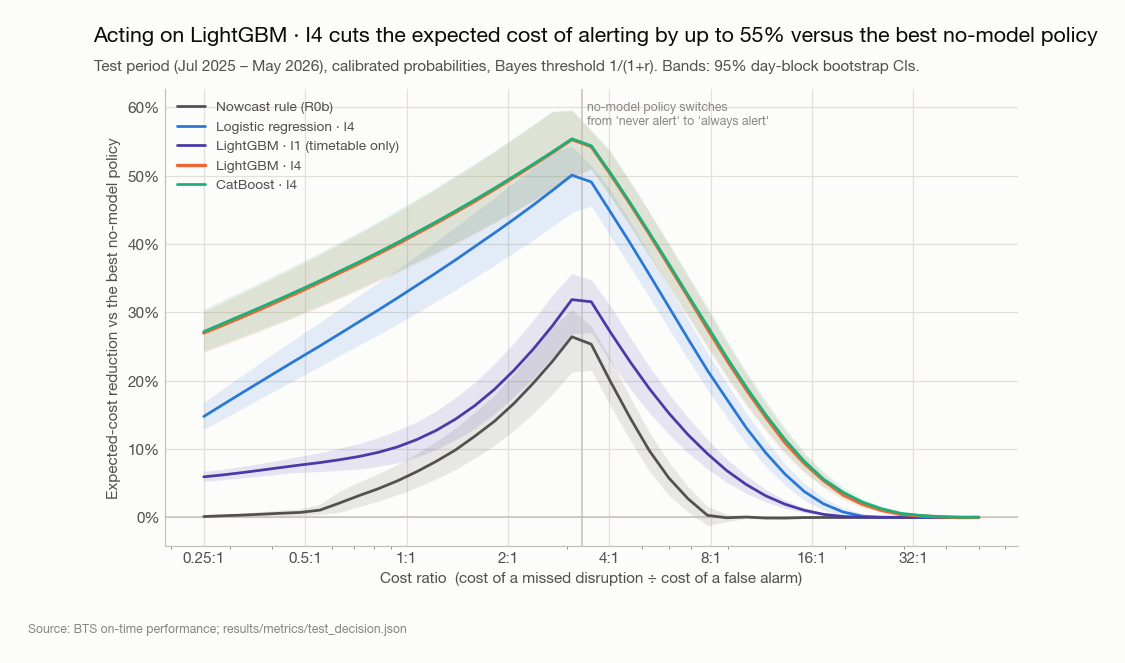

In [3]:
show("fig00_hero_cost")

## 1 · The problem, and what "pays off" means

Airlines, airports and travellers act on disruption risk hours before departure: they re-sequence crews,
protect connections, re-book passengers, or simply leave for the airport later. A useful forecast has to be
**available early**, **honest about its probability**, and **worth acting on**.

The project asks one question: **when does model complexity actually pay off?** The last project in this line
(v1) found that fancy "regime" features added nothing, and its test set was too small to say much with confidence.
This version is built to answer the question properly:

| Lens | What we measure | Why it matters |
|---|---|---|
| Probability quality (**primary**) | Brier score, reported as **Brier Skill Score (BSS) vs climatology**; calibration (ECE, reliability) | The product *is* a probability; a proper scoring rule rewards honest ones |
| Ranking | PR-AUC, ROC-AUC | Who should be looked at first |
| Decision value | Expected cost of an alert policy across cost ratios | A model only pays off if acting on it is cheaper |
| Stability | Performance by month, season, airport, carrier, stress days, and a backward test on 2021 | Deployed models live through drift |
| Compute | Fit time, rows, trees | Complexity has a running cost |

**Design choices, each defended below:** a flight-level target with cancellations included; a strict as-of rule tested
automatically; chronological splits with a validation year that covers every season; a model × information grid that
separates *what the model knows* from *what the model is*; pre-registered hypotheses; and a day-block bootstrap on every
headline number.

## 2 · Data: a forensic audit before any modelling

**Source.** Monthly BTS Reporting Carrier On-Time Performance extracts (Jan 2021 – May 2026), one CSV per month,
delivered as a third-party archive. Nothing is trusted until it is checked: every file is audited **one month at a
time** (the raw CSVs are never all in memory) and written to compact typed parquet.

**What the audit found.** Three kinds of problem, all handled explicitly rather than silently:
1. **Spreadsheet damage.** In many files the `FL_DATE` column has two formats split *exactly* between day 12 and day 13,
   the fingerprint of a file opened and re-saved in a spreadsheet using a day-first (DD/MM) locale: days 1–12 were
   re-interpreted as dates, days 13+ stayed as text. **Decision:** `FL_DATE` is never used; dates are rebuilt from
   `YEAR / MONTH / DAY_OF_MONTH`, and every other field is checked against internal invariants.
2. **Schema drift.** Some months carry an extra `CANCELLATION_CODE` column; one has a blank `YEAR` header; one has an
   empty junk column. **Decision:** map columns by name onto a canonical schema, and fail loudly on anything unknown.
3. **Tiny holes.** A missing flight number, and a few dozen missing scheduled block times. **Decision:** sentinel /
   route-median imputation, counted and reported.

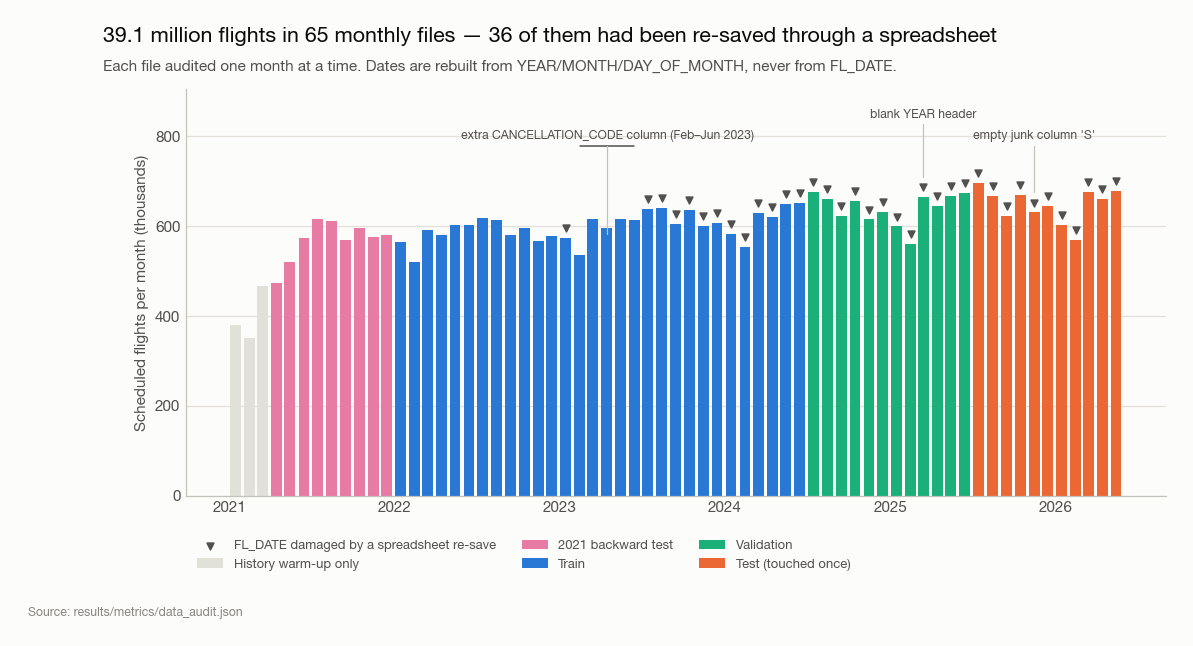

Check,Result
Monthly files,65
Flights (rows),"39,073,000"
Row parity raw CSV → parquet,exact
Files with FL_DATE damaged by a spreadsheet re-save (days 1-12 reformatted),36
Files with schema anomalies,7
Calendar days missing,0
Duplicate flight keys,0
Rows with missing flight number,1
Rows with missing / non-positive scheduled block time,34
Worst-file pass rate: dep time equals crs plus delay,99.993%


File,Anomaly,Handling
Feb-2023.csv,optional columns present: ['CANCELLATION_CODE'],mapped by name; optional column kept for insight only
Mar-2023.csv,optional columns present: ['CANCELLATION_CODE'],mapped by name; optional column kept for insight only
Apr-2023.csv,optional columns present: ['CANCELLATION_CODE'],mapped by name; optional column kept for insight only
May-2023.csv,optional columns present: ['CANCELLATION_CODE'],mapped by name; optional column kept for insight only
Jun-2023.csv,optional columns present: ['CANCELLATION_CODE'],mapped by name; optional column kept for insight only
Mar-2025.csv,blank first header cell mapped to YEAR (values verified),blank header cell mapped to YEAR after checking values
Nov-2025.csv,junk column 'S' (must be empty),junk column dropped after asserting it is empty


In [4]:
show("fig01_data_audit")
table(st.audit_summary())
table(st.schema_anomalies())

The invariants are close to perfect across all files. For example, *actual departure = scheduled time + DEP_DELAY*,
and *delay-cause columns are present if and only if the flight arrived 15+ min late*. That is strong evidence the
spreadsheet re-save changed the date column's text and nothing else.

## 3 · Building a trustworthy clock

All clock times in the data are **local to each airport**. Ordering events across airports, which "was the inbound
aircraft already in the air at t\*?" requires, needs a single clock. Two independent sources:

* **IANA time zones** for every airport (public `airportsdata` package + Python `zoneinfo`, DST exact); and
* **offsets derived from the schedules themselves**: `local arrival − local departure − scheduled block time` equals the
  destination-minus-origin offset. Per DST period we take the modal difference on every route and solve for all
  airport offsets at once by least squares on the route graph, anchored at Atlanta.

Timestamps are then built in UTC: `sched_arr = sched_dep + block time` (no next-day guessing),
`actual departure = sched_dep + DEP_DELAY` (never parsing `DEP_TIME`, which contains `2400` and midnight crossings).

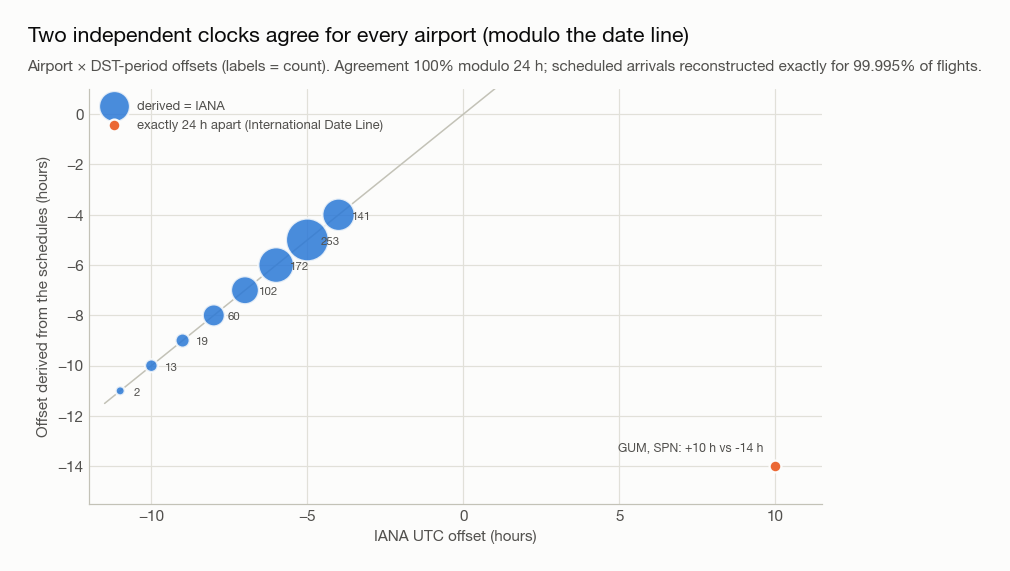

Check,Result
Airports / with an IANA time zone,387 / 387
Derived offsets agreeing with IANA (airport × DST period),99.48%
... agreeing modulo 24 h,100.00%
Airports differing by exactly 24 h (date line),"GUM, SPN"
Scheduled arrivals reconstructed exactly from UTC,99.995%
Scheduled next-day arrivals handled,"1,653,733"
Delayed departures crossing local midnight,"212,421"
Departures in a DST-ambiguous / non-existent local hour,35
"Gate-return cancellations (pushed back, then cancelled)","8,854"
Scheduled block times imputed (route median),34


In [5]:
show("fig02_tz_check")
table(st.tz_summary())

The only "disagreements" are Guam and Saipan, where the two methods differ by **exactly 24 hours**. That is the
International Date Line, which a modulo-24-hour derivation cannot see. It is a nice confirmation, not a bug.

## 4 · The target, and the moment of prediction

**Unit and target.** One row per scheduled flight. `y = 1` if the flight was **cancelled or departed 15+ min late**.

*Why include cancellations?* The conventional target (`DEP_DEL15` on operated flights) silently drops cancelled flights.
But at t\* nobody knows which flights will be cancelled, and cancellations cluster on the worst days, so dropping them
makes the hardest days look easy and conditions on the future. Our target is defined for **every** scheduled flight.
Diverted flights did depart and are labelled by their departure delay.

**The as-of rule.** `t* = scheduled departure − 2 h`. A feature may use a record only if that record was observable at
or before t\*. Every event carries the time it becomes observable:

| Event about another flight | Observable at |
|---|---|
| It exists in the timetable (route, times, aircraft) | before t\* |
| It pushed back, and with what delay | its actual push-back time |
| It is **known to be disrupted** | 15 min after its scheduled departure if it has not left (true for long delays *and* cancellations) |
| It landed, and with what delay | its actual arrival time |
| A cancellation that happened after an on-time push-back | conservatively, 24 h after schedule |

**Leakage is tested, not promised.** The time-travel test rebuilds features from a copy of the database truncated to
exactly what was known at t\* (every later push-back, landing and outcome hidden) and requires *bit-identical* features.
A deliberately leaky "canary" feature must fail the same test.

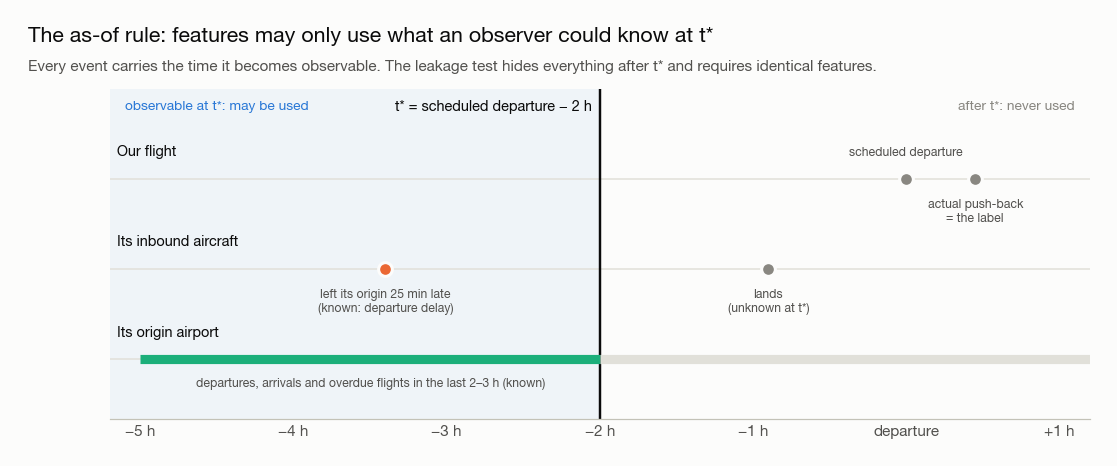

test,outcome,seconds
test_app_parity::test_app_probability_matches_pipeline,passed,0.205000
test_app_parity::test_app_bundle_is_small,passed,0.000000
test_app_parity::test_app_runs_headless_and_responds_to_inputs,passed,0.766000
test_bootstrap::test_histogram_metrics_match_exact,passed,0.063000
test_bootstrap::test_paired_bootstrap_detects_real_difference_and_not_noise,passed,0.221000
test_bootstrap::test_block_weights_preserve_total_days,passed,0.001000
test_engine_primitives::test_stab_matches_brute_force,passed,0.006000
test_engine_primitives::test_window_count_matches_brute_force,passed,0.002000
test_engine_primitives::test_never_is_outside_every_window,passed,0.000000
test_labels_and_time::test_label_definition,passed,1.867000


In [6]:
show("fig03_asof_timeline")
table(st.tests_table())

## 5 · What disruption looks like (development period only)

Outcome rates for the test year and for 2021 stay **masked** until the final evaluation, so the design could not
be tuned to them. Everything in this section uses January 2022 – June 2025.

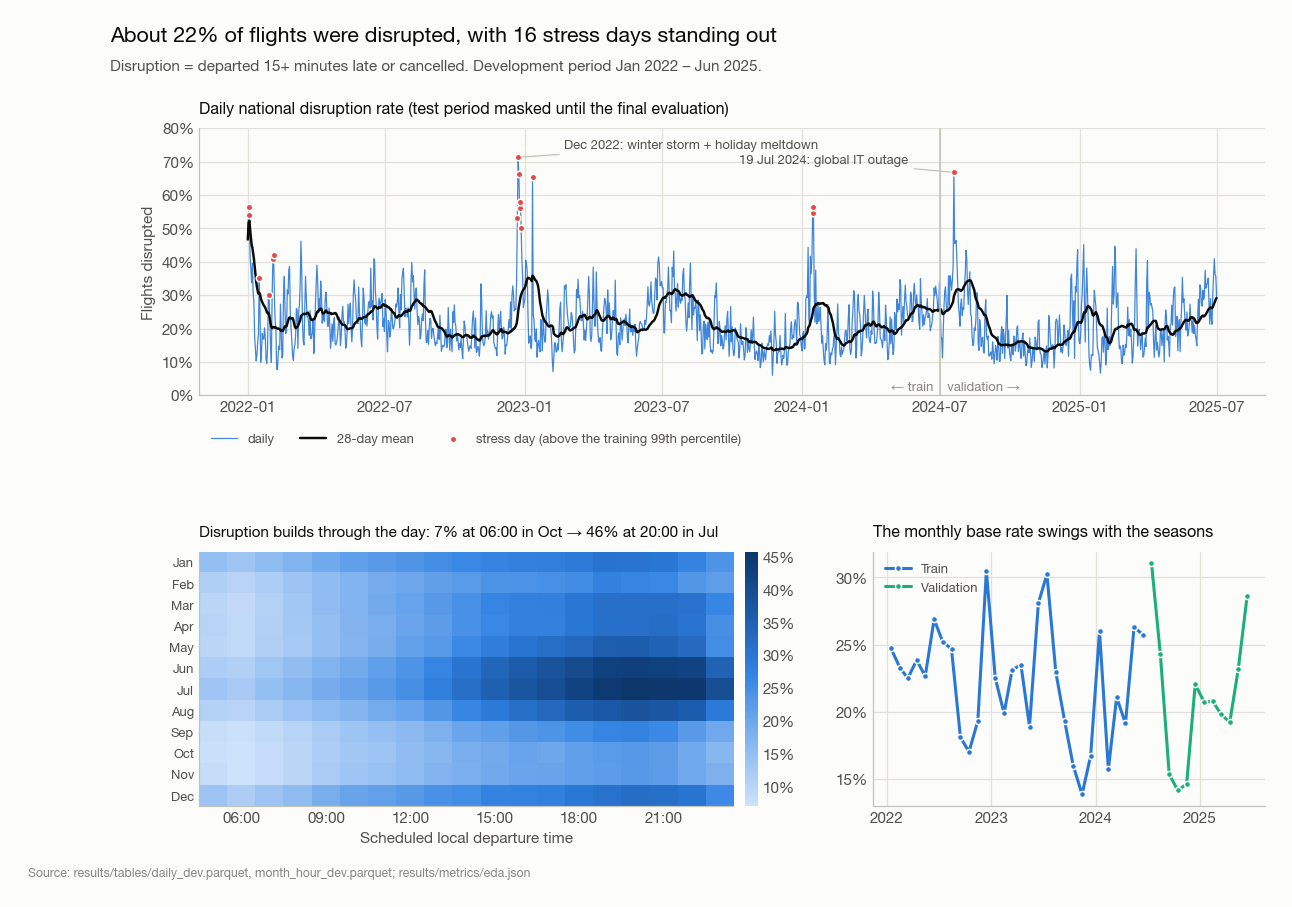

- Development period: **25,648,606 flights over 1277 days**; 22.0% disrupted (train 22.3%, validation 21.3%); 1.74% cancelled.
- Time of day dominates: from 7% at the calmest hour-month to 46% at the busiest, because delay accumulates through the day.
- **16 stress days** exceed the training 99th percentile (53% disrupted or 17% cancelled). The worst is 2022-12-23 (71.3% disrupted).
- **19 Jul 2024** (the global IT outage) is detected: 66.8% of flights disrupted and 15.9% cancelled; flagged as a stress day: **True**.
- BTS's own cause attribution puts **39% of delay minutes on late-arriving aircraft**, the largest single cause (post-outcome data, insight only).

Date,Flights,Disrupted,Cancelled,Carrier with most cancellations,Its cancellation rate
2022-12-23,"19,867",71.3%,27.7%,AS,72.5%
2024-07-19,"22,861",66.8%,15.9%,G4,58.8%
2022-12-24,"15,365",66.4%,21.6%,WN,43.7%
2023-01-11,"18,376",65.3%,6.8%,OH,28.9%
2022-12-26,"19,228",58.0%,20.9%,WN,77.5%
2022-01-02,"20,038",56.5%,13.0%,OO,25.3%
2024-01-16,"17,574",56.5%,13.0%,YX,36.7%
2022-12-25,"15,738",56.1%,20.3%,WN,51.6%
2024-01-15,"19,804",54.6%,16.6%,OH,29.0%
2022-01-03,"20,166",54.0%,15.9%,OH,35.6%


In [7]:
show("fig04_disruption_landscape")
md(st.eda_md())
table(st.anomaly_table())

Stress days were flagged automatically (above the training period's 99th percentile of daily disruption or
cancellation rate) and only then named. The 19 July 2024 IT outage and the December 2022 winter-storm meltdown are
both **verified in the data**, not assumed. Because the outage falls in the validation year, it tested the models
out of sample during development.

## 6 · The network view: airports and aircraft rotations

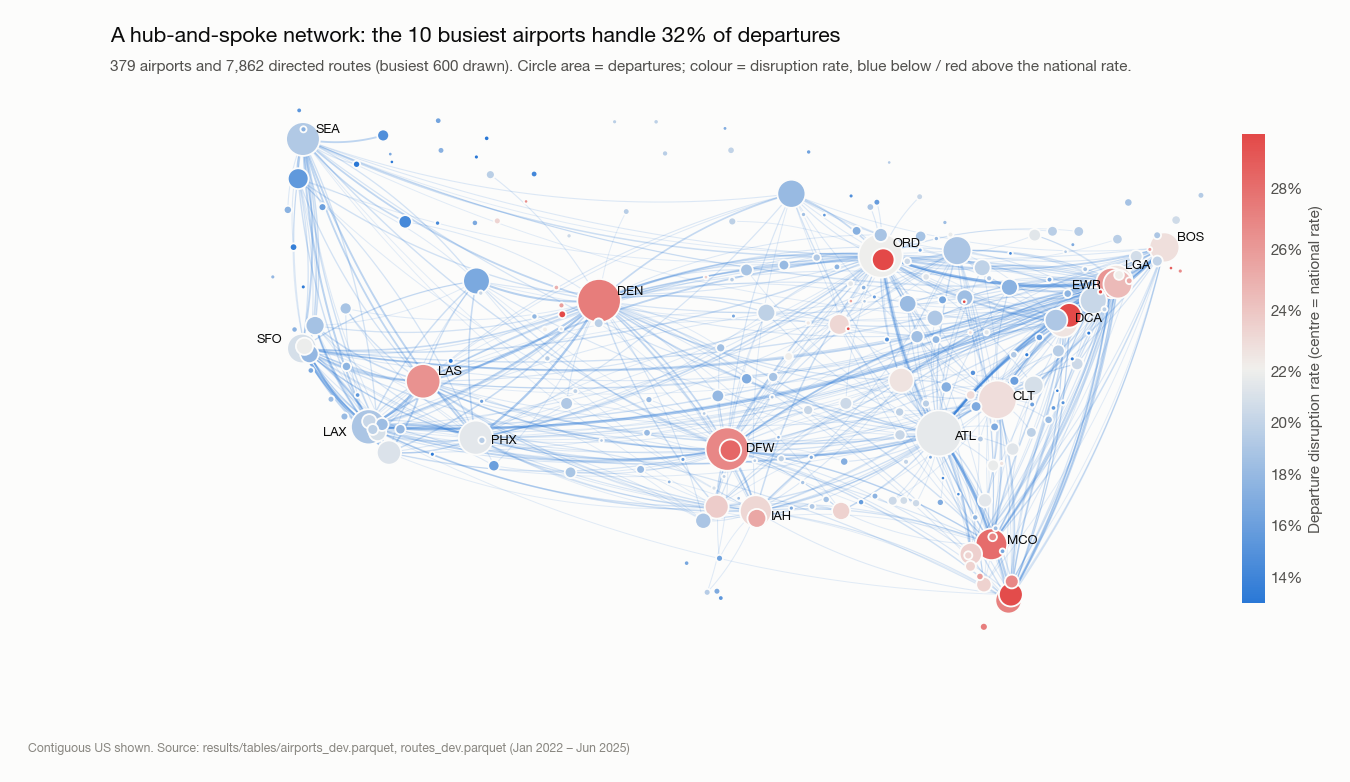

In [8]:
show("fig05_network_map")

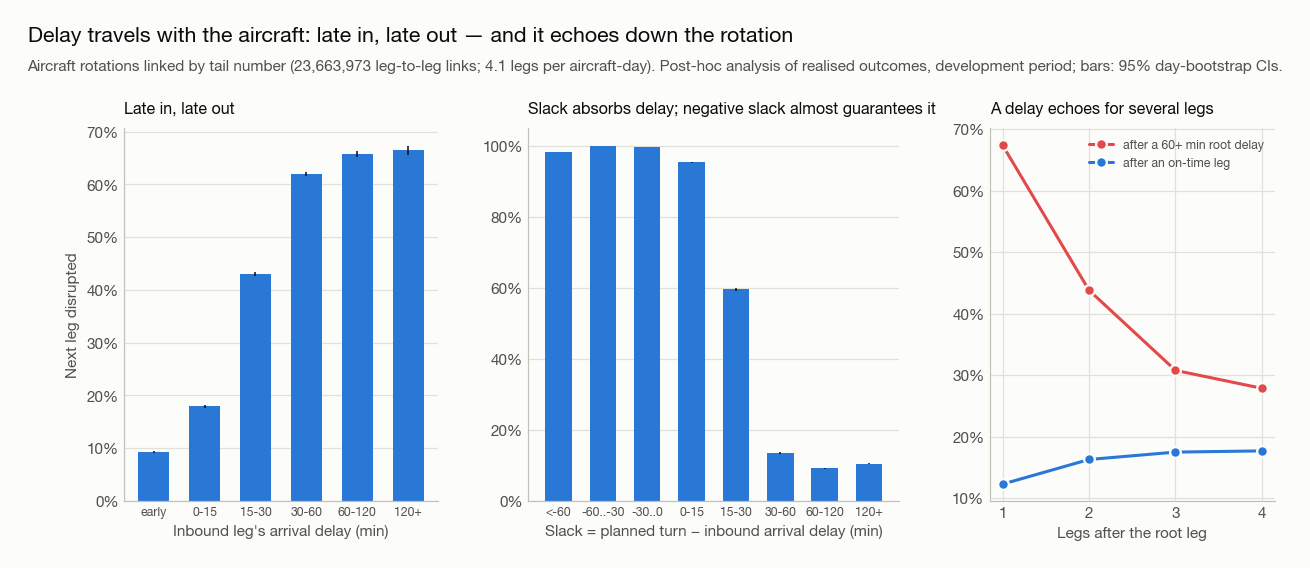

- 23,663,973 leg-to-leg links; aircraft fly 4.1 legs a day on average; only 1.9% of consecutive legs break continuity (a tail that lands at A and next departs from B).
- The next leg is disrupted 18% of the time after an inbound that arrived 0–15 min late, versus 66% after one that arrived 60–120 min late.
- After a 60+ min root delay, the next legs are disrupted 67% → 44% → 31% → 28% of the time, against about 16% after an on-time leg: a delay echoes for several legs before it is absorbed.

In [9]:
show("fig06_propagation")
md(st.propagation_md())

**What this implies for modelling.** Delay is carried by aircraft: a plane that lands late departs late, and the
effect decays over several legs. At t\* the *status of the inbound aircraft* (not yet departed, airborne with a known
delay, or landed) is observable, so it becomes a feature family (**I3**). The flights heading into the origin airport
become another (**I4**). These analyses use realised outcomes and are descriptive only. The delay-cause columns are
post-outcome and never enter a model.

## 7 · Features: five nested information sets

Features are organised by **what an observer would need to know**, so the ladder can separate information from
model class:

* **I1 · timetable + history**: calendar, route, scheduled congestion, the aircraft's planned rotation, and trailing
  28-day disruption rates (lagged 3 days, empirical-Bayes shrunk toward the national rate).
* **I2 · + live airport state**: in the last 2–3 hours at the origin, destination, carrier network and nation: push-backs
  and their delays, flights still at the gate past schedule, arrivals, and the share of flights already known to be
  disrupted.
* **I3 · + inbound aircraft**: live status of the aircraft's previous leg at t\*, its known delay, the projected slack,
  and the state of the airport it is coming from.
* **I4 · + network**: flights scheduled to arrive at the origin in the next 3 hours (how many are already late,
  still at their gate, or airborne with delay), plus static connectivity.
* **I5 · + regimes**: posterior probabilities of a Gaussian mixture fitted on training-period network states
  (a replication of v1's idea).

**Engineering note for reviewers.** Every live-state feature is "how many intervals contain t\*": a flight is in the
state *departed within the last 2 h* during `[dep, dep + 120)`. That count is `#(start ≤ t*) − #(end ≤ t*)`: two
`searchsorted` calls over sorted, group-offset keys. This is exact, fully vectorised (build time per month is recorded
in `results/metrics/features_h120.json`), and as-of by construction because intervals are built only from observable times.

In [10]:
table(st.feature_sets())

Set,Adds,Features added,Cumulative,Examples
I1,Timetable + history,29,29,"dep_hour, dep_hour_sin, dep_hour_cos, dow"
I2,+ live airport state,18,47,"org_known_late_share_3h, org_sched_n_3h, org_dep_n_2h, org_dep_late_share_2h"
I3,+ inbound aircraft,10,57,"inb_status, inb_not_landed, inb_overdue_min, inb_dep_delay_known"
I4,+ network,6,63,"up_sched_n_3h, up_known_late_share_3h, up_airborne_mean_dep_delay, up_overdue_share"
I5,+ regimes,4,67,"regime_p0, regime_p1, regime_p2, regime_p3"


## 8 · Splits and pre-registration

**Chronological only.** The original proposal validated on January–June 2025. I changed it because the calibrator and
the conformal quantiles are *fitted* on validation data, so validation must contain a full seasonal cycle (summer
thunderstorms, holiday peaks). Otherwise calibration is learned on the wrong season, which is exactly how v1's
prevalence drift bit. Validation is also split into interleaved weeks: odd ISO weeks (**V-A**) fit early stopping and
the calibrators; even weeks (**V-B**) select calibrators, calibrate conformal sets, and give honest validation numbers.
Both halves span every season.

**Pre-registration.** Hypotheses, the primary metric, the smallest effect size of interest (a 1% relative Brier
improvement), the Holm-adjusted comparison family, conformal and decision rules, and the "holds / breaks" thresholds were
written to `configs/preregistration.yaml` and hashed **before any model was evaluated**. The test year was then
evaluated exactly once, by a script that refuses to run unless every frozen model file matches its recorded hash.

In [11]:
table(st.split_table())
table(st.prereg_table())
md(st.freeze_md())

Role,Months,Note
Backward stress test,2021-04 … 2021-12,"evaluated once, at the end"
Train,2022-01 … 2024-06,disruption rate 22.3%
Validation,2024-07 … 2025-06,disruption rate 21.3%
Test,2025-07 … 2026-05,masked until the single final evaluation


ID,Comparison,Pre-registered expectation
H1,LightGBM-I2 vs R0 climatology,better
H2,LightGBM-I3 vs LightGBM-I2,better; largest info gain
H3,LightGBM-I4 vs LightGBM-I3,small or not significant
H4,CatBoost-I4 vs LightGBM-I4,practically equivalent (|diff| < SESOI)
H5,LightGBM-I5 vs LightGBM-I4,no lift (< SESOI)
H6,LightGBM-I4 vs Logistic regression-I4,better; gap at I4 > gap at I1


Pre-registration SHA-256 `84a0e20280ee671b…`, frozen at 2026-09-28T19:01:03+00:00 (before any ladder evaluation).

## 9 · The model ladder

| Rung | Model | Why it is on the ladder |
|---|---|---|
| R0 | **Climatology**: hierarchical empirical-Bayes rate by origin × carrier × month × 3-hour block | the "no machine learning" prior, and the skill-score reference |
| R0b | **Nowcast rule**: climatology blended with the origin's live known-late share (one weight) | a transparent operations heuristic; guards against beating a straw man |
| R1 | **Logistic regression**: logit-scale rates, log counts, periodic hour splines, one-hot categoricals | the strongest simple model |
| R2 | **LightGBM** | the workhorse gradient-boosted trees |
| R3 | **CatBoost**: native categorical handling and ordered boosting | does a fancier GBM help? |

**Fair tuning, and one honest amendment.** Pre-registered budgets: 3 values of C for LR and 8 configurations for
LightGBM, tuned on I4 with the same tuning sample and early stopping on V-A; hyper-parameters are then reused across
information sets. CatBoost was also pre-registered at 8 configurations, but one CatBoost configuration cost roughly an
order of magnitude more wall time than a LightGBM one on this laptop. **Amendment A1** (dated and hashed *before* any
validation-B or test evaluation) truncates its search to 3 configurations and refits it at I4 only. A truncated search
can only understate CatBoost, so a CatBoost win would be conservative. All models are trained on the same 4 million
training flights (Jan 2022 – Jun 2024) and calibrated on validation before evaluation. Compute cost is itself one of
the five lenses: see the table.

In [12]:
table(st.tuning_table())
table(st.compute_table())

Family,Configurations,Best V-A log loss,Mean seconds per configuration,Best configuration
Logistic regression,3,0.36747,—,C=0.1
LightGBM,8,0.33294,93,"num_leaves=255, min_child_samples=100, reg_lambda=10.0"
CatBoost,3,0.33053,1040,"depth=6, l2_leaf_reg=3.0, random_strength=0.5"


Model,Rows used,Fit seconds,Trees / iterations
R0 climatology,all training flights,nan,—
R0b nowcast rule,None,0.000000,—
Logistic regression · I1,1500000,6.000000,None
Logistic regression · I2,1500000,14.000000,None
Logistic regression · I3,1500000,19.000000,None
Logistic regression · I4,1500000,24.000000,None
LightGBM · I1,4000000,55.000000,99
LightGBM · I2,4000000,176.000000,544
LightGBM · I3,4000000,217.000000,614
LightGBM · I4,4000000,221.000000,591


## 10 · Validation results (V-B, development)

In [13]:
table(st.ladder_table("val_ladder"))

Model,Brier skill vs R0,PR-AUC,ROC-AUC,Brier,Log loss,ECE
R0 climatology,"0.0% [0.0, 0.0]","34.1% [28.5, 37.1]","65.7% [63.5, 67.1]",0.1609,0.4969,0.0120
R0b nowcast rule,"4.9% [3.6, 6.1]","41.6% [35.7, 44.8]","69.4% [67.6, 70.3]",0.1530,0.4780,0.0056
Logistic regression · I1,"8.5% [7.7, 9.0]","46.6% [41.1, 49.4]","72.1% [70.3, 73.1]",0.1472,0.4620,0.0087
Logistic regression · I2,"13.9% [12.4, 15.1]","52.4% [47.1, 55.3]","75.8% [74.4, 76.5]",0.1385,0.4393,0.0028
Logistic regression · I3,"28.9% [27.8, 29.9]","66.5% [62.6, 68.7]","82.5% [81.4, 83.0]",0.1143,0.3770,0.0024
Logistic regression · I4,"29.1% [27.9, 30.1]","66.6% [62.7, 68.8]","82.5% [81.5, 83.0]",0.1140,0.3762,0.0026
LightGBM · I1,"11.2% [10.3, 11.7]","50.5% [45.4, 53.0]","73.8% [72.1, 74.8]",0.1429,0.4499,0.0111
LightGBM · I2,"19.2% [17.6, 20.6]","58.6% [53.7, 61.3]","78.5% [77.2, 79.1]",0.1300,0.4161,0.0031
LightGBM · I3,"37.1% [35.8, 38.1]","73.6% [70.2, 75.6]","85.3% [84.4, 85.7]",0.1012,0.3387,0.0023
LightGBM · I4,"37.2% [35.9, 38.3]","73.7% [70.3, 75.7]","85.4% [84.4, 85.8]",0.1010,0.3381,0.0024


### More data, or more information?
Before touching the test year: the same LightGBM, trained on nested subsets of the training flights, with the timetable
alone (I1) or with live, inbound-aircraft and network information (I4). This is validation data only.

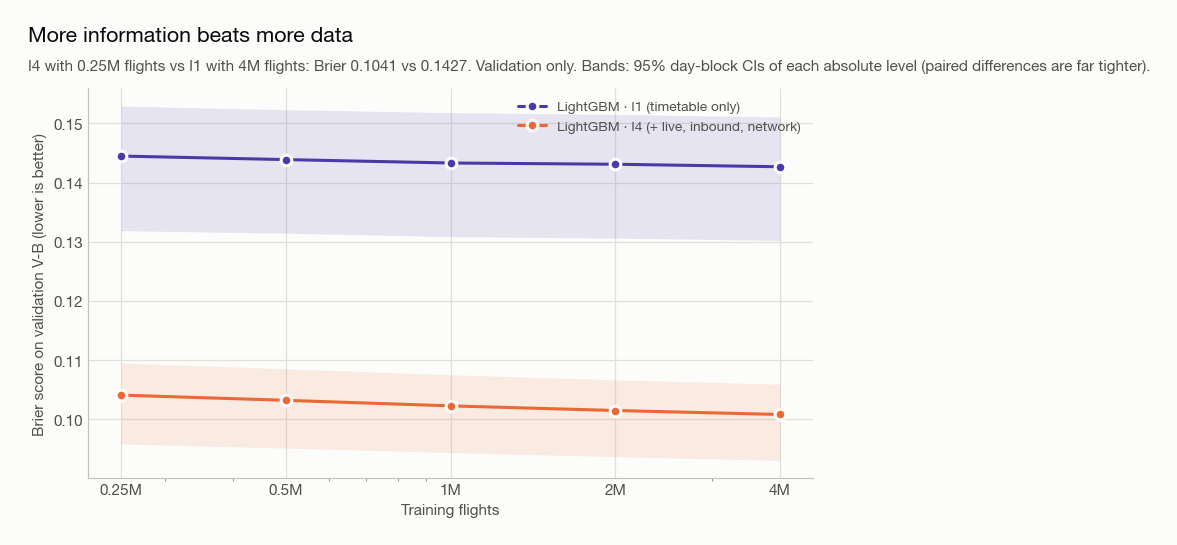

**Fairness check (exploratory, validation V-B only).** The pre-registered rule reuses I4-tuned hyper-parameters for every information set, which could handicap the timetable-only model. Giving LightGBM · I1 its own 8-configuration search changes its Brier score by -0.06% [-0.19, +0.08]; the I4 model's advantage is +29.33% [+28.27, +30.20] over the pre-registered I1 and +29.36% [+28.35, +30.22] over the separately tuned I1. The information-versus-complexity conclusion does not depend on the tuning rule.

In [14]:
show("fig15_learning_curve")
md(st.sensitivity_md())

## 11 · The test year, evaluated once

July 2025 – May 2026, never seen during development. Models are frozen at the June 2024 training cut-off, so the
test is also a stress test of **staleness**: 13–23 months after training.

In [15]:
md(st.access_md())
table(st.ladder_table("test_ladder"))

Test-set access log: **1 access(es)**, first at 2026-09-28T22:28:14+00:00 by `scripts/evaluate.py final` (frozen model hashes verified: True).

Model,Brier skill vs R0,PR-AUC,ROC-AUC,Brier,Log loss,ECE
R0 climatology,"0.0% [0.0, 0.0]","35.0% [32.3, 37.3]","64.6% [63.2, 65.7]",0.1703,0.5203,0.0300
R0b nowcast rule,"5.9% [4.4, 7.5]","43.4% [40.0, 46.4]","69.2% [68.3, 70.0]",0.1603,0.4959,0.0166
Logistic regression · I1,"9.5% [8.7, 10.4]","48.3% [45.7, 50.7]","72.3% [71.5, 73.1]",0.1541,0.4785,0.0196
Logistic regression · I2,"15.6% [13.9, 17.6]","54.6% [51.6, 57.3]","76.3% [75.5, 77.0]",0.1438,0.4519,0.0059
Logistic regression · I3,"30.3% [28.9, 31.8]","68.0% [66.0, 69.8]","82.7% [82.2, 83.2]",0.1187,0.3885,0.0067
Logistic regression · I4,"30.4% [29.1, 32.0]","68.2% [66.2, 70.0]","82.8% [82.3, 83.3]",0.1185,0.3877,0.0066
LightGBM · I1,"11.7% [10.5, 13.0]","51.3% [48.7, 53.8]","73.6% [72.6, 74.4]",0.1503,0.4677,0.0073
LightGBM · I2,"20.8% [19.1, 22.8]","60.5% [57.9, 63.0]","78.9% [78.2, 79.5]",0.1349,0.4281,0.0029
LightGBM · I3,"38.0% [36.7, 39.5]","74.7% [72.9, 76.4]","85.4% [84.9, 85.9]",0.1056,0.3508,0.0034
LightGBM · I4,"38.1% [36.8, 39.6]","74.8% [73.0, 76.4]","85.5% [85.0, 85.9]",0.1054,0.3501,0.0032


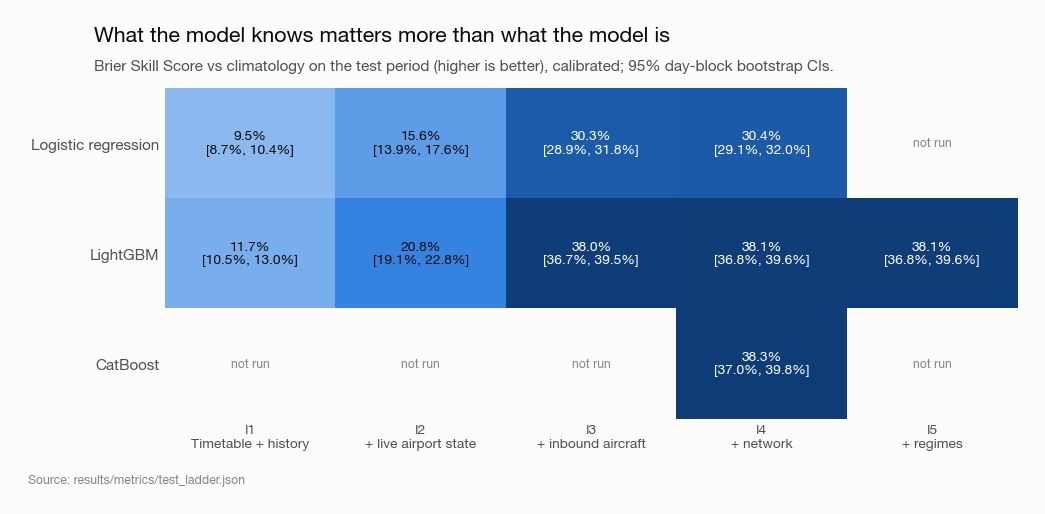

In [16]:
show("fig07_info_model_grid")

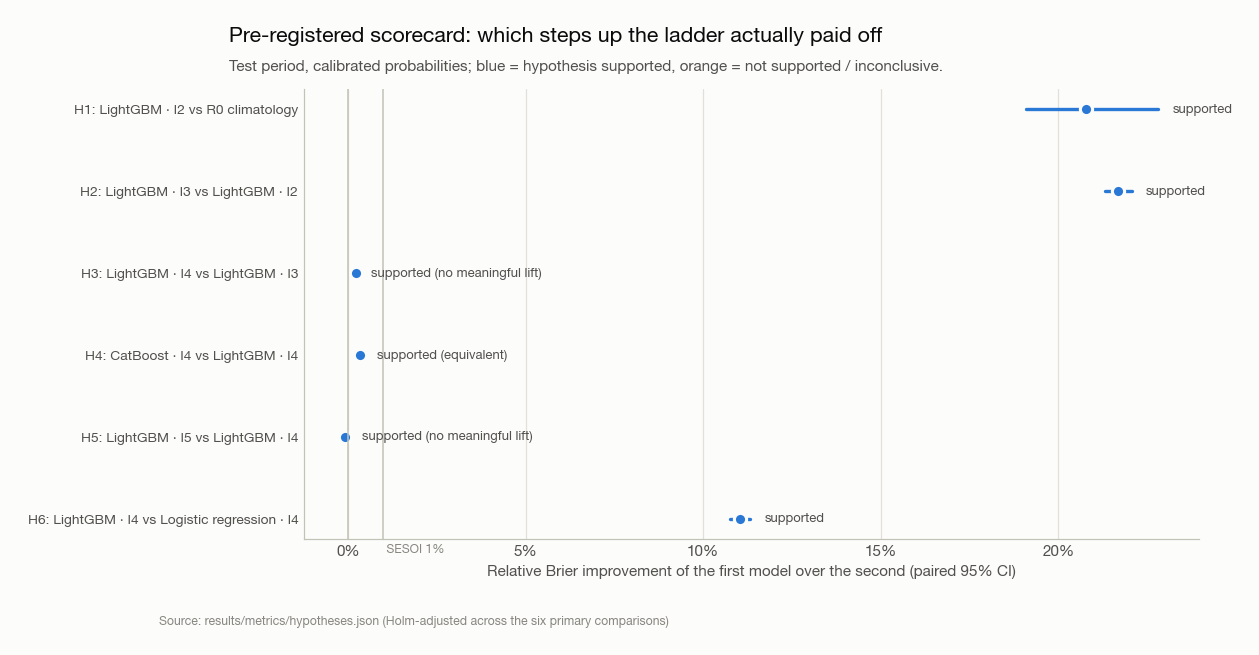

ID,Comparison,Relative Brier improvement [95% CI],Holm p,Reading,Verdict (pre-registered rule)
H1,LightGBM · I2 vs R0 climatology,"20.79% [19.09, 22.81]",< 0.0005,significantly better,supported
H2,LightGBM · I3 vs LightGBM · I2,"21.69% [21.32, 22.07]",< 0.0005,significantly better,supported
H3,LightGBM · I4 vs LightGBM · I3,"0.22% [0.18, 0.26]",< 0.0005,"significantly better, but below the 1% margin",supported (no meaningful lift)
H4,CatBoost · I4 vs LightGBM · I4,"0.34% [0.27, 0.42]",< 0.0005,"significantly better, but below the 1% margin",supported (equivalent)
H5,LightGBM · I5 vs LightGBM · I4,"-0.08% [-0.10, -0.06]",< 0.0005,significantly worse,supported (no meaningful lift)
H6,LightGBM · I4 vs Logistic regression · I4,"11.03% [10.75, 11.33]",< 0.0005,significantly better,supported


In [17]:
show("fig08_ladder_forest")
table(st.hypotheses_table())

In [18]:
md(st.ladder_md())
md(st.secondary_md())

**Reading the ladder (relative Brier improvement, paired 95% CI):**

| Step | Kind | Improvement | Verdict |
|---|---|---|---|
| I1 → I2 (live airport state) | information | +10.3% [+8.8, +11.8] | **pays off** (significant, above the 1% margin) |
| I2 → I3 (inbound aircraft) | information | +21.7% [+21.3, +22.1] | **pays off** (significant, above the 1% margin) |
| I3 → I4 (network) | information | +0.2% [+0.2, +0.3] | significant but below the 1% margin: negligible |
| I4 → I5 (regimes) | information | -0.1% [-0.1, -0.1] | significantly **worse** |
| LR → LightGBM at I4 | model class | +11.0% [+10.7, +11.3] | **pays off** (significant, above the 1% margin) |
| LR → LightGBM at I1 | model class | +2.4% [+1.4, +3.4] | **pays off** (significant, above the 1% margin) |
| LightGBM → CatBoost at I4 | model class | +0.3% [+0.3, +0.4] | significant but below the 1% margin: negligible |

**Secondary pre-registered hypotheses**

| ID | Hypothesis | Verdict |
|---|---|---|
| H7 | GNN does not beat aggregated LightGBM | not tested in this version |
| H8 | Calibration lowers ECE for every rung; monthly bias drifts with prevalence | partly supported: ECE fell for 9 of 12 models; the predicted monthly drift with prevalence did not appear (r = -0.01) |
| H9 | Split conformal under-covers disrupted flights / high-disruption months; ACI shrinks the gap | supported: disrupted-flight coverage 60.9% (target 90%); monthly coverage vs prevalence r = -0.97; ACI shrinks the mean monthly gap (0.7 pp → 0.6 pp at γ=0.005, 0.4 pp at γ=0.05) |
| H10 | The live-information gain shrinks as the horizon grows | supported |

## 12 · Probabilities you can trust

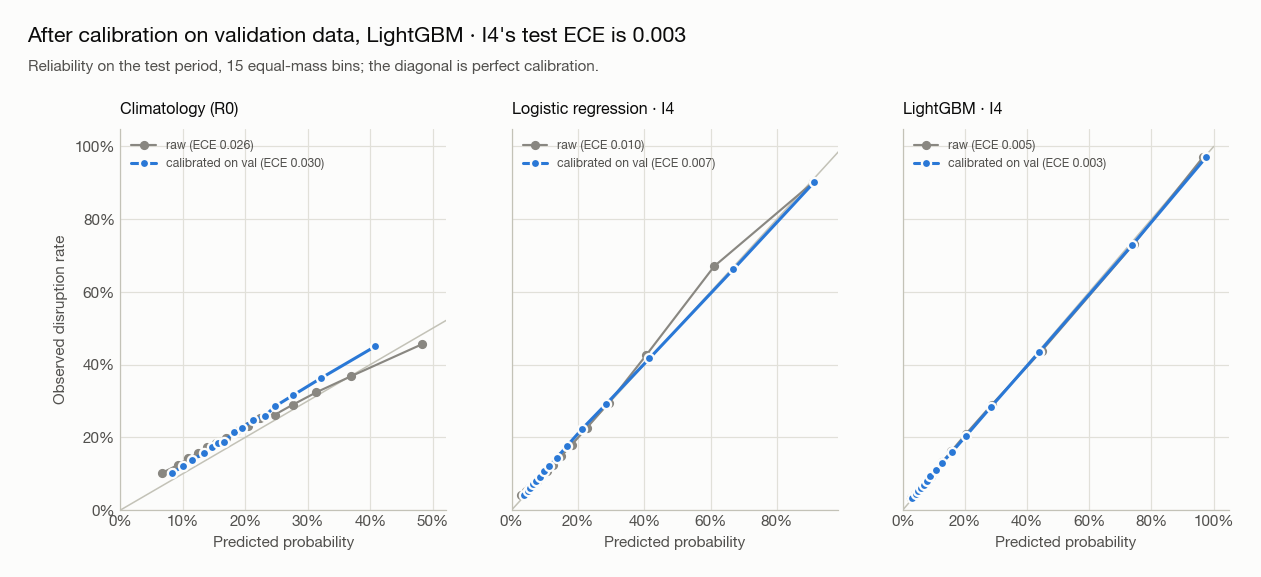

Model,Brier,Reliability (↓),Resolution (↑),Uncertainty,ECE raw → calibrated
R0 climatology,0.1703,0.00096,0.0088,0.1782,0.0255 → 0.0300
R0b nowcast rule,0.1603,0.00029,0.0179,0.1782,0.0339 → 0.0166
Logistic regression · I4,0.1185,0.00005,0.0593,0.1782,0.0096 → 0.0066
LightGBM · I1,0.1503,0.00008,0.0265,0.1782,0.0087 → 0.0073
LightGBM · I4,0.1054,0.00002,0.0722,0.1782,0.0052 → 0.0031
CatBoost · I4,0.1050,0.00002,0.0726,0.1782,0.0031 → 0.0035


In [19]:
show("fig09_reliability")
table(st.murphy_table())

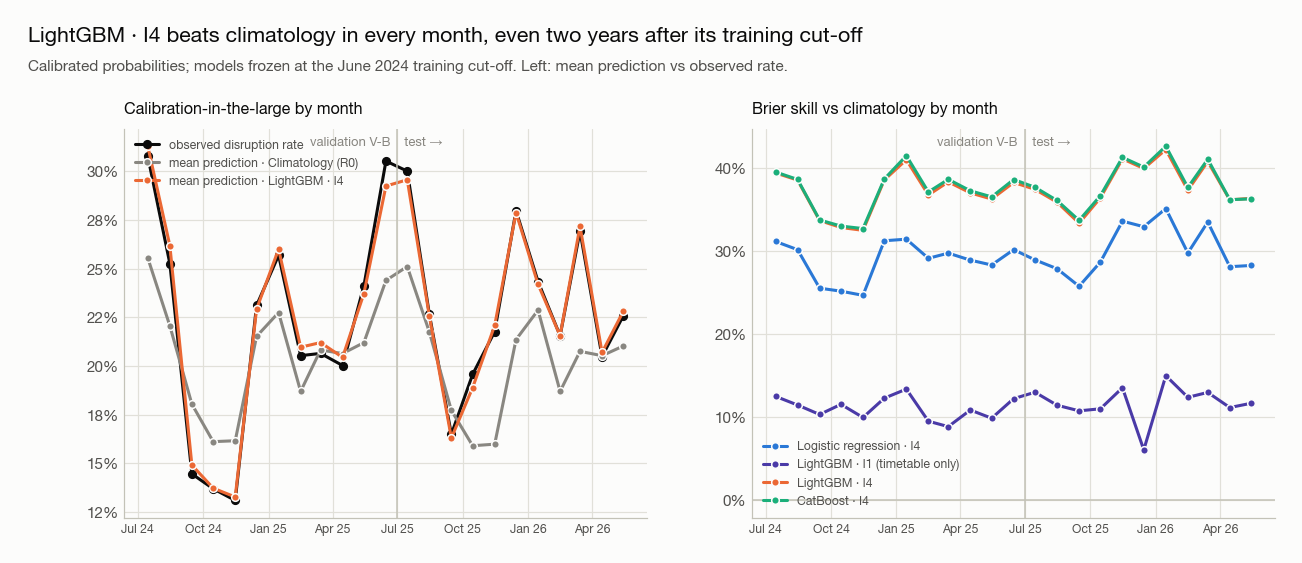

- Validation-fitted calibration lowered test ECE for **9 of 12** models; it did not for R0 climatology, Logistic regression · I1, CatBoost · I4.
- Brier decomposition: the models differ almost entirely in **resolution** (how well they separate risky from safe flights); the reliability term is tiny for every calibrated model.
- Month by month, LightGBM · I4's average prediction misses the observed rate by between -0.7 and +0.3 percentage points, and the miss shows no systematic relation to the month's prevalence (r = -0.01). A calibrator fitted on a full validation year transfers to the next year, even with the model frozen.

In [20]:
show("fig10_calibration_drift")
md(st.calibration_md())

## 13 · Honest uncertainty: conformal prediction sets

For each flight the model returns a set that should contain the true outcome 90% of the time: `{on time}`,
`{disrupted}`, or `{either}` when it cannot tell. Split conformal guarantees this only if calibration and test data are
exchangeable, and flight delays drift. So instead of assuming the guarantee, we **measure** it: overall, for disrupted
flights specifically, by month, and with an adaptive variant (ACI) that updates its error rate once a day as outcomes
arrive.

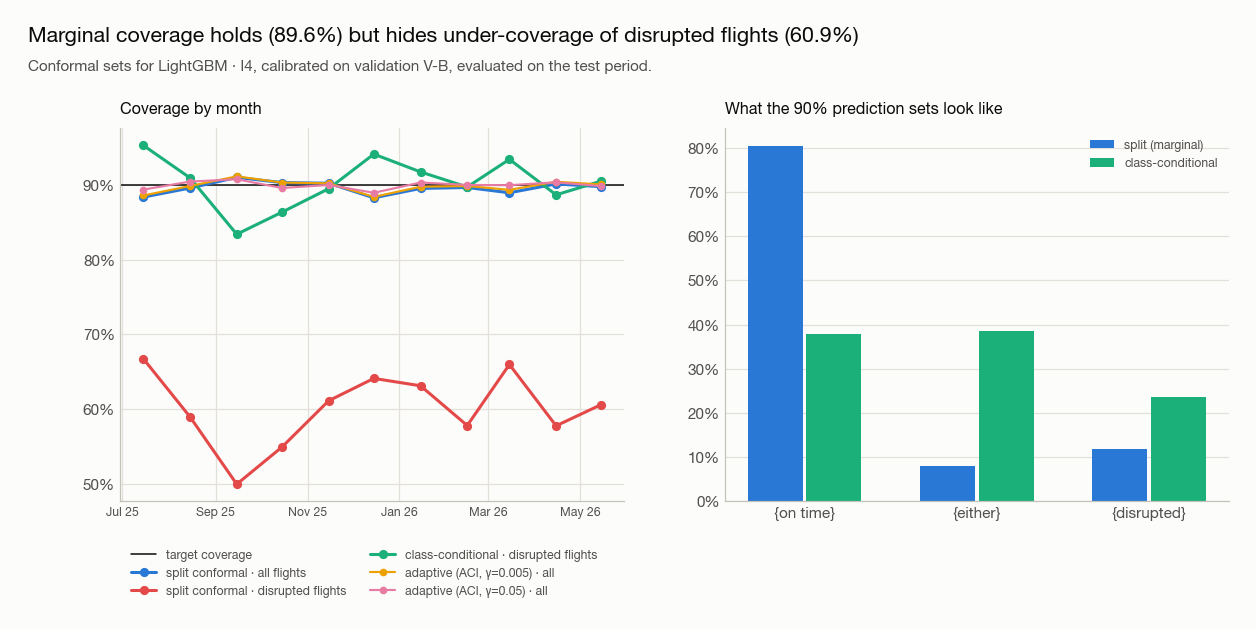

- Target coverage 90%. **Split conformal: 89.6% overall**, but 60.9% on disrupted flights and 98.3% on on-time flights. Marginal validity hides who pays for it.
- **Class-conditional (Mondrian) conformal** fixes the split by class: 90.9% on disrupted and 89.3% on on-time flights, at the price of more `{either}` sets (38% vs 8%).
- Mean absolute monthly coverage gap: split 0.7 pp; ACI γ=0.005: 0.6 pp, γ=0.05: 0.4 pp. Overall ACI coverage: γ=0.005: 89.8%, γ=0.05: 89.9%.
- Read the sets honestly: with a 20%-ish base rate, a 90% guarantee is often met by `{on time}` or `{either}`, so conformal sets communicate *how sure* the model is rather than flagging many flights as surely disrupted.

In [21]:
show("fig11_conformal")
md(st.conformal_md())

## 14 · From probability to decision: where each rung pays off

Suppose each flight can trigger an **alert** (protect the connection, re-crew, re-book). A false alarm costs 1 unit;
a missed disruption costs *r* units. With calibrated probabilities the cost-minimising rule is simple: alert when
`p ≥ 1/(1+r)`. We compare every model with the best **no-model** policy (always alert, or never alert, whichever is
cheaper at that *r*) and with the rung below it.

In [22]:
table(st.decision_table())

Cost ratio (miss : false alarm),Bayes threshold,R0b nowcast rule,Logistic regression · I4,LightGBM · I1,LightGBM · I4,CatBoost · I4
0.94 : 1,0.52,5.3%,32.1%,10.3%,40.0%,40.2%
2.1 : 1,0.32,16.6%,43.6%,21.5%,49.7%,49.9%
3.1 : 1,0.24,26.4%,50.1%,31.9%,55.3%,55.4%
4 : 1,0.20,19.8%,44.6%,27.0%,50.2%,50.3%
7.8 : 1,0.11,0.3%,21.5%,9.3%,27.6%,28.0%
15 : 1,0.06,-0.0%,3.8%,1.0%,7.9%,8.2%


In [23]:
md("**Incremental saving of each step, per 1,000 flights, in false-alarm units** (paired 95% CI: *pays* = CI above zero, *n.s.* = not significant).")
table(st.increments_table())
md(st.decision_md())

**Incremental saving of each step, per 1,000 flights, in false-alarm units** (paired 95% CI: *pays* = CI above zero, *n.s.* = not significant).

Step up the ladder,r=0.94,r=2.1,r=4,r=7.8,r=15
R0b nowcast rule over R0 climatology,+11.1 (pays),+47.9 (pays),+59.6 (pays),+9.1 (pays),-0.2 (costs)
Logistic regression · I4 over R0b nowcast rule,+58.4 (pays),+130.3 (pays),+190.5 (pays),+162.8 (pays),+29.2 (pays)
LightGBM · I1 over R0 climatology,+22.0 (pays),+71.4 (pays),+115.0 (pays),+78.3 (pays),+7.9 (pays)
LightGBM · I4 over Logistic regression · I4,+17.2 (pays),+29.6 (pays),+42.5 (pays),+46.7 (pays),+31.7 (pays)
LightGBM · I4 over LightGBM · I1,+64.8 (pays),+136.5 (pays),+177.7 (pays),+140.3 (pays),+52.7 (pays)
CatBoost · I4 over LightGBM · I4,+0.5 (pays),+0.8 (pays),+1.2 (pays),+3.0 (pays),+2.3 (pays)


- **R0b nowcast rule** over **R0 climatology**: significant saving for cost ratios 0.25–38; largest at r ≈ 3.1 (+67.0 false-alarm units per 1,000 flights).
- **Logistic regression · I4** over **R0b nowcast rule**: significant saving for cost ratios 0.25–20; largest at r ≈ 5.3 (+197.9 false-alarm units per 1,000 flights).
- **LightGBM · I1** over **R0 climatology**: significant saving for cost ratios 0.25–50; largest at r ≈ 4 (+115.0 false-alarm units per 1,000 flights).
- **LightGBM · I4** over **Logistic regression · I4**: significant saving for cost ratios 0.25–38; largest at r ≈ 6.9 (+47.2 false-alarm units per 1,000 flights).
- **LightGBM · I4** over **LightGBM · I1**: significant saving for cost ratios 0.25–38; largest at r ≈ 4 (+177.7 false-alarm units per 1,000 flights).
- **CatBoost · I4** over **LightGBM · I4**: significant saving for cost ratios 0.25–34; largest at r ≈ 13 (+3.5 false-alarm units per 1,000 flights).
- At very high cost ratios every sensible policy alerts on almost every flight, so the rungs converge; that is where extra complexity stops paying off by construction.

## 15 · Where it holds, where it breaks

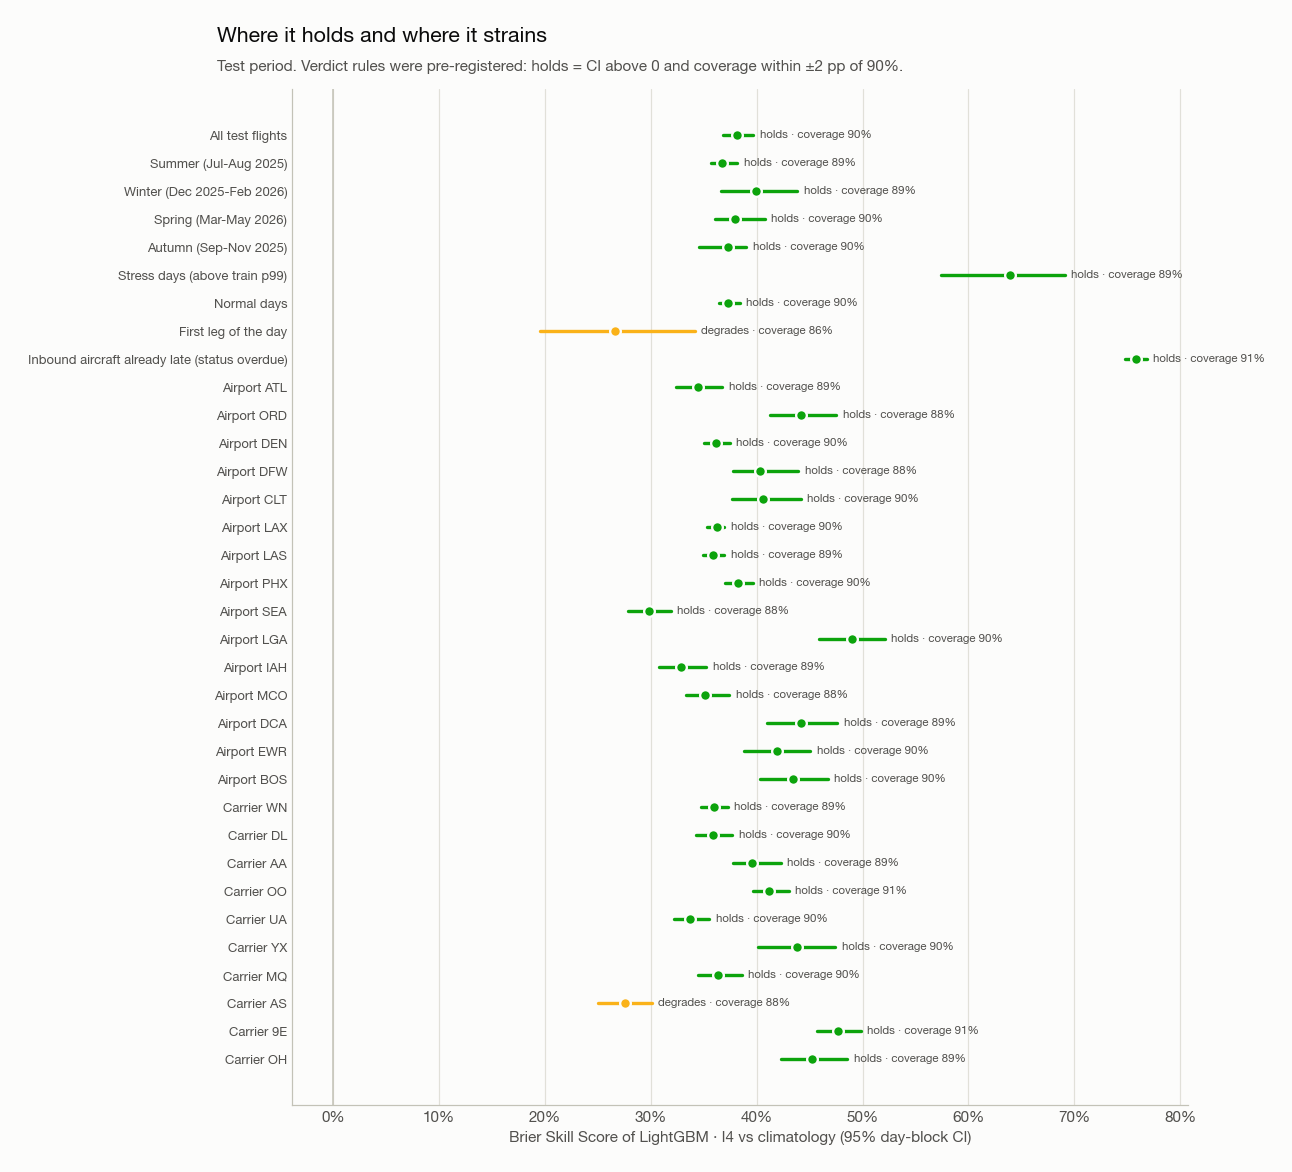

Segment,Flights,Disruption rate,BSS LightGBM·I4 [95% CI],90% set coverage,Verdict
All test flights,"7,112,523",23.2%,"38.1% [36.8, 39.7]",89.6%,holds
Summer (Jul-Aug 2025),"1,362,291",26.4%,"36.7% [35.6, 38.2]",89.0%,holds
Winter (Dec 2025-Feb 2026),"1,816,729",24.8%,"40.0% [36.7, 43.9]",89.1%,holds
Spring (Mar-May 2026),"2,013,382",23.4%,"38.0% [36.1, 40.7]",89.6%,holds
Autumn (Sep-Nov 2025),"1,920,121",19.3%,"37.3% [34.5, 39.0]",90.5%,holds
Stress days (above train p99),"102,359",53.1%,"63.9% [57.4, 69.1]",88.7%,holds
Normal days,"7,010,164",22.8%,"37.3% [36.5, 38.4]",89.6%,holds
First leg of the day,"412,078",26.5%,"26.7% [19.5, 34.1]",86.3%,degrades
Inbound aircraft already late (status overdue),"407,954",78.6%,"75.8% [74.8, 76.9]",90.8%,holds
Airport ATL,"320,351",22.7%,"34.5% [32.4, 36.8]",89.3%,holds


In [24]:
show("fig12_holds_breaks")
table(st.robustness_table())

In [25]:
md(st.backtest_md())
table(st.ladder_table("backtest_2021", keys=["R0", "R0b", "LR-I4", "LGBM-I1", "LGBM-I4", "CB-I4"]))

**Backward stress test: April–December 2021** (recovery from the pandemic, before any training data; 5,115,191 flights). LightGBM · I4 BSS 34.2% [33.2, 34.8] vs climatology fitted on 2022–24.

Model,Brier skill vs R0,PR-AUC,ROC-AUC,Brier,Log loss,ECE
R0 climatology,"0.0% [0.0, 0.0]","35.4% [31.6, 38.8]","67.0% [65.9, 67.9]",0.1506,0.4728,0.0104
R0b nowcast rule,"3.5% [2.5, 4.1]","40.1% [36.2, 42.8]","69.4% [68.3, 70.1]",0.1453,0.4595,0.0026
Logistic regression · I4,"27.2% [26.2, 27.9]","64.8% [62.1, 66.9]","82.3% [81.6, 82.7]",0.1097,0.3647,0.0074
LightGBM · I1,"11.8% [10.9, 12.4]","51.4% [48.1, 54.2]","75.3% [74.4, 76.0]",0.1328,0.4250,0.0136
LightGBM · I4,"34.2% [33.2, 34.8]","71.2% [68.7, 73.1]","84.7% [84.1, 85.1]",0.0991,0.3338,0.0023
CatBoost · I4,"34.5% [33.5, 35.1]","71.5% [69.0, 73.4]","84.9% [84.3, 85.3]",0.0987,0.3323,0.0028


## 16 · What drives a prediction

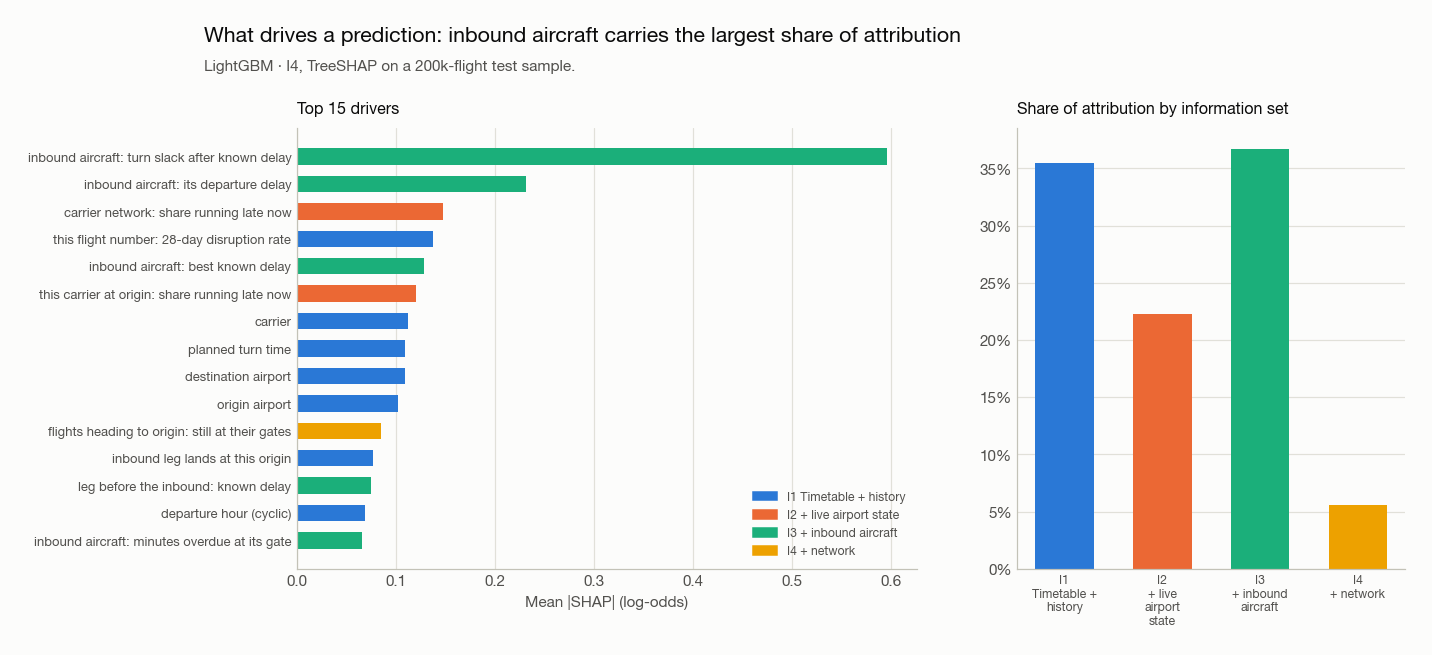

In [26]:
show("fig13_shap")

## 17 · Horizon: when does live information pay off?

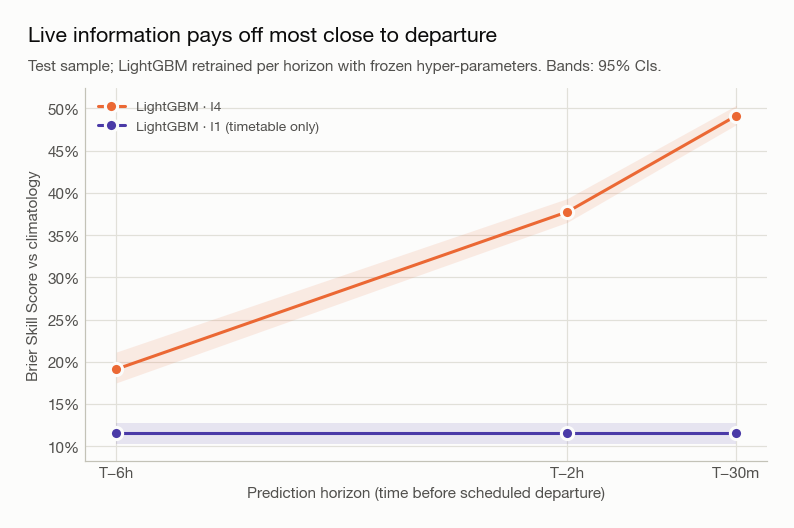

Relative Brier improvement of LightGBM · I4 (live + network information) over LightGBM · I1 (timetable only): **T−30 min**: 42.5% [41.5, 43.7]; **T−2 h**: 29.6% [28.5, 30.9]; **T−6 h**: 8.6% [7.2, 10.1]. Pre-registered H10: **supported**.

In [27]:
show("fig14_horizon")
md(st.horizon_md())

## 18 · Conclusions: when does complexity pay off?

In [28]:
md(st.conclusions_md())

**When does complexity pay off? What the evidence supports:**

1. **Information first.** The significant information steps add 32.2% relative Brier improvement for LightGBM, against 11.0% for switching LR → LightGBM at I4. Knowing where the aircraft is and what the airport is doing right now matters more than the algorithm, and the learning curve shows a small model with rich information beating a large one without it.
2. **Trees pay off once there is something to interact with.** LightGBM over LR: +2.4% [+1.4, +3.4] with timetable information only, +11.0% [+10.7, +11.3] with live and network information (H6: supported).
3. **A fancier booster is not the answer.** CatBoost vs LightGBM at I4: +0.3% [+0.3, +0.4], statistically real but inside the pre-registered 1% margin (H4: supported (equivalent)), at many times the training cost (section 9).
4. **Network features and regimes add nothing that matters.** I3 → I4: +0.2% [+0.2, +0.3]; I4 → I5: -0.1% [-0.1, -0.1]. Once the inbound aircraft is known, the rest of the network is mostly redundant, and v1's regime null result replicates on a far larger test set.
5. **Decision value is largest where decisions are hardest.** The saving over the best no-model policy peaks at 55% near a 3.1 : 1 cost ratio, where the no-model policy flips from 'never alert' to 'always alert'. At extreme ratios every policy converges, and complexity stops paying.
6. **Live information is perishable.** Relative Brier improvement of LightGBM · I4 (live + network information) over LightGBM · I1 (timetable only): **T−30 min**: 42.5% [41.5, 43.7]; **T−2 h**: 29.6% [28.5, 30.9]; **T−6 h**: 8.6% [7.2, 10.1]. Pre-registered H10: **supported**.
7. **Trust has to be measured, not assumed.** Calibration transferred across a year with a frozen model, but split-conformal sets under-covered disrupted flights until they were made class-conditional.

**What I would do next:** retrain monthly and recalibrate weekly (skill held for two years, so this is about incremental gains rather than rescue); add public METAR weather and FAA ground-delay programmes as information set I6; give CatBoost its full search budget on a bigger machine; and test a spatio-temporal GNN against the airport-hour aggregate of LightGBM · I4.

## 19 · Limitations (read these before trusting any number)

* **Aircraft swaps are invisible.** BTS records the tail that actually flew. Last-minute swaps, which are common on bad
  days, cannot be seen, so inbound-aircraft features are somewhat optimistic. Treat the I3 gain as an upper bound.
* **Cancellation timing is unknown.** Some cancellations were announced before t\* and would already be known to a
  traveller. The as-of rule treats them conservatively, which understates what a real system could know.
* **No weather or ATC programme data.** Live airport state is a proxy for weather and ground-delay programmes. Public
  METARs would be a natural next information set.
* **Frozen models.** Everything is trained to June 2024 and never retrained. A production system would retrain monthly,
  so the test year is a conservative (stale-model) estimate.
* **Third-party archive.** The files show spreadsheet artefacts. Internal invariants hold almost everywhere, but the
  official BTS files were not re-downloaded for a byte-level cross-check.
* **CatBoost is budget-limited.** Under amendment A1 it had 3 configurations instead of 8, and its final fit used almost
  its full 3,000-iteration cap. Its small edge over LightGBM is therefore a conservative estimate.
* **The GNN rung was not run** in this version (hypothesis H7 is reported as *not tested*). The flight-level GBM with
  explicit network features is the comparison a GNN would have to beat.

## 20 · Reproducibility

In [29]:
md(st.repro_md())

- Python 3.11.14, LightGBM 4.7.0, CatBoost 1.2.10, scikit-learn 1.7.2 (pinned in `uv.lock`); seed `20260929`.
- Tests: **22 passed, 0 failed, 0 skipped** (`make test`).
- Frozen artefacts: 22 files hashed in `models/FROZEN.json`.
- Rebuild everything from the raw zip: `make env && make all`. Stages that already exist are skipped; `python -m flightrisk.pipeline` shows the order.